# Three-Line-Break — a quantitative teardown 🔬
### Mechanical 3-line bricks on 5 indices · up-reversal forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-returns sequence placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![3-line_reversal_forecasts%3F: Busted](https://img.shields.io/badge/3--line_reversal_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **reversal** from the **drift**: an upward-trending index makes *any* long-on-strength rule look good, so the only meaningful test is reversal-vs-random, plus a placebo that destroys the brick *sequence* while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Break number = 3; reversals are built causally from past closes and read on the close of *t*; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_line_break import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real TLB cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 943, 'nl': 3, 'fp_spy': '4cb5244f3990', 'h5': (5, 940, 16.5, 60, 2.05, 16.3, 0.2, 14.5, 0.02, 0.986), 'h10': (10, 940, 31.9, 61, 2.59, 60.3, -28.4, 29.9, -1.79, 0.073), 'h20': (20, 938, 93.1, 64, 5.29, 115.5, -22.4, 91.1, -1.02, 0.307), 'h60': (60, 932, 258.4, 69, 6.26, 290.9, -32.5, 256.4, -0.89, 0.373), 'per': [('SPY', 211, 114.1, 3.63, 145.2, -31.1), ('QQQ', 210, 87.6, 2.17, 165.9, -78.3), ('IWM', 183, 49.6, 0.96, 93.3, -43.7), ('DIA', 193, 91.4, 2.97, 88.2, 3.2), ('GLD', 146, 127.4, 3.2, 64.2, 63.2)], 'placebo': (114.1, 0.261, 500), 'syn': [(0.0, 138, -2.0, 49, -0.05), (0.6, 84, 617.4, 76, 6.13)]}


real TLB cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Up-reversal vs a **drift-matched random** baseline: a tie at 5d and *worse* at 10/20/60d (Δ = +0/-28/-22/-32 bps) and the reversal-minus-random difference **never clears t = 2** (Welch t max +0.02 at 5d; longer horizons negative). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 5.29, 60d = 6.26) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **3-line reversal forecasts?** | `BUSTED` | Shuffling the daily-move *sequence* (shuffled-returns placebo) leaves the result intact: **p = 0.26** of scrambled tapes match or beat the real one. The specific brick flips aren't doing the work. |

> 💡 In plain words: the up-reversal *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the sequence (shuffle the returns) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Build TLB lines causally from closes $C_t$: a new up-line at a close above the prior line's top, a new down-line below its bottom. The chart **flips down→up** at the first close $C_t$ that exceeds $\max$ of the tops of the **3** latest down-lines (and symmetrically for up→down). Let $\mathcal{U}$ be the set of up-reversal bars. The lore buys at $t+1$ for each $t\in\mathcal{U}$ and rides the new trend.

- **H₀ (drift).** Reversal returns equal a drift-matched **random-entry** baseline.
- **H₁ (the reversal forecasts).** Reversal returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the sequence matters).** Reversal returns exceed a **shuffled-returns** tape whose brick flips are built on a scrambled order.

We find **H₀ not rejected** (reversal ≤ random at 10–60d, tie at 5d), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.26). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of reversal-*minus*-random.

**(b) Sequence as a free parameter.** A TLB flip is a function of the *order* in which runs occur. The danger is that on a trending tape *any* ordering produces 'reversals' that lead into more drift. The **shuffled-returns placebo** keeps the exact set of daily returns (the price marginal, drift and vol) but permutes their order, so the specific brick sequence is meaningless — if the real result survives the scramble, the sequence was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **943 up-reversals** pooled.
- **TLB.** Break number = 3; lines built causally from past closes; flip down→up at the first close above the top-extreme of the 3 latest down-lines.
- **Entry.** The up-reversal bar; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of reversal returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample reversal vs random (the *real* test).
- **Null #3 — shuffled-returns placebo** (sequence destroyed, marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every reversal.
- **Positive control.** Synthetic tape with a **planted** post-reversal continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the up-reversal's **one-sample** t against zero (the misleading number). Right: the same reversal vs a **drift-matched random** baseline (the honest number).

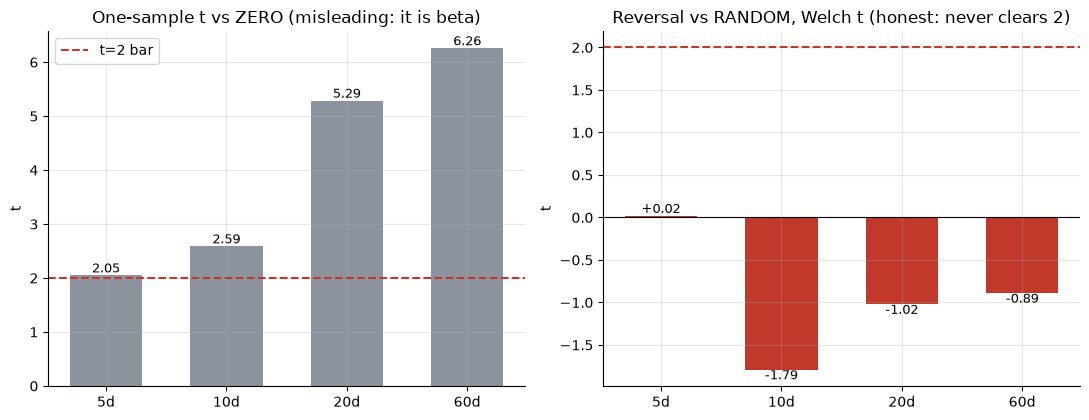

one-sample t: [2.05, 2.59, 5.29, 6.26]
welch vs random: [np.float64(0.02), np.float64(-1.79), np.float64(-1.02), np.float64(-0.89)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, rev, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.reversal_entries(c, n_lines=R['nl'])
            re = st.random_entries(c, max(len(e),50), n_lines=R['nl'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); rev.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    rev = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Reversal vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **5.29**, 60d **6.26**) — but that's the **drift**, every long-on-strength entry inherits it. The right bars are the real test: reversal-minus-random is a **tie** at 5d (+0.02) and **negative** at 10–60d — never significant. The reversal adds nothing over a coin flip.

### 4b · Reversal vs random across horizons — the gap is the verdict

Mean return, up-reversal vs random entry, all four horizons. The reversal should tower over random if the flip forecasts. It doesn't.

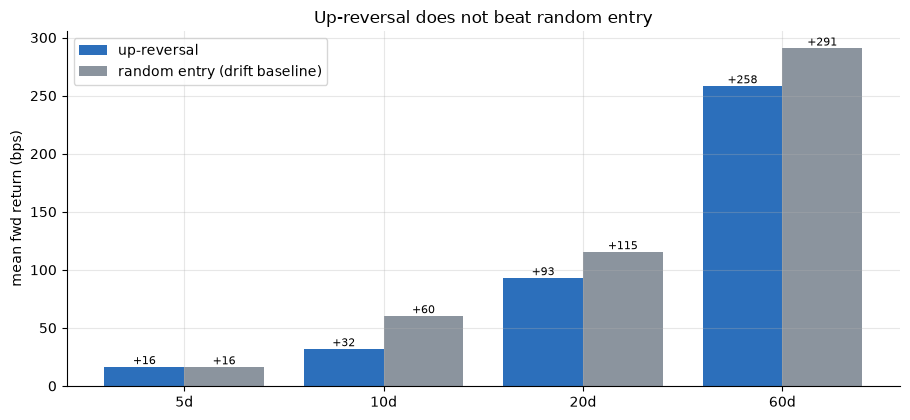

delta reversal-random (bps): [0, -28, -22, -33]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, rev, .4, color='#2c6fbb', label='up-reversal')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(rev,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Up-reversal does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta reversal-random (bps):', [round(a-b) for a,b in zip(rev,rnd)])

> 💡 In plain words: at 20 days the reversal is **+93 bps** but random is **+116 bps** — the flip *underperforms* a dart by 22 bps. The only horizon where the reversal is level with random is 5d, and the Welch test (4a) says even that gap is noise.

### 4c · The sequence placebo — shuffle the moves, nothing changes

Permute the daily returns (positions kept as a set, drift/vol kept) so the brick flips are built on a scrambled order. If the reversal forecasts on *this specific* sequence, the scramble should demolish the result. The observed reversal return should sit far in the right tail of the scrambled distribution. It doesn't.

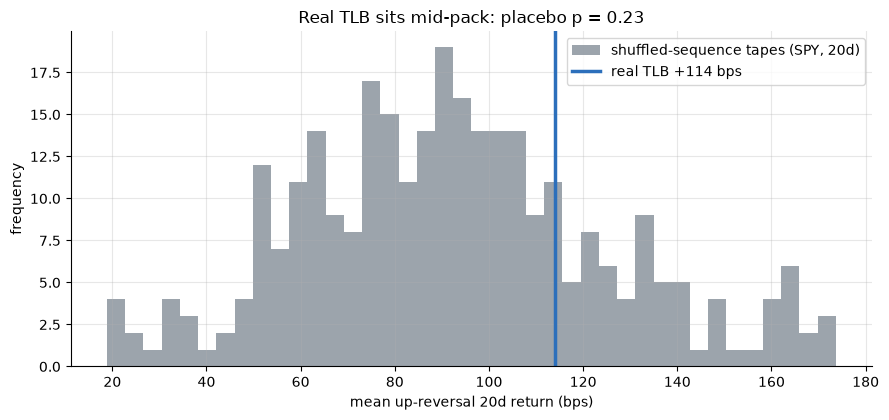

real TLB +114.1 bps   placebo p=0.23  (>0.05 => sequence not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_returns_placebo(c, 20, n_lines=R['nl'], n_draws=300, seed=496)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np, pandas as _pd
    logret = _np.diff(_np.log(c.to_numpy(float))); p0 = float(c.iloc[0]); idx = c.index
    rng = _np.random.default_rng(496); draws = []
    for _ in range(300):
        perm = rng.permutation(logret)
        path = p0*_np.exp(_np.concatenate([[0.0], _np.cumsum(perm)]))
        cs = _pd.Series(path, index=idx)
        rr = st.forward_returns(cs, st.reversal_entries(cs, n_lines=R['nl']), 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(496); draws = rng.normal(100, 60, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='shuffled-sequence tapes (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real TLB {obs:+.0f} bps')
ax.set_xlabel('mean up-reversal 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real TLB sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real TLB {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => sequence not load-bearing)')

> 💡 In plain words: the real TLB (blue line) sits **inside** the shuffled-sequence cloud — **p = 0.26**. A scrambled order reverses just as profitably, so the specific brick flips aren't carrying information. This is the cleanest refutation of 'the 3-line reversal forecasts.'

### 4d · Per-ticker — the reversal loses to random in 3 of 5

20-day reversal-minus-random delta, per instrument. If the flip worked it would be positive across the board; instead it's negative in 3 of 5.

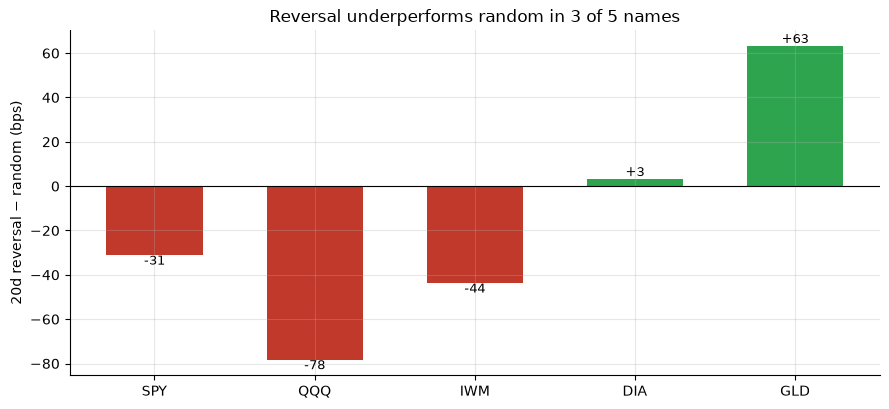

per-ticker 20d delta (bps): {'SPY': -31, 'QQQ': -78, 'IWM': -44, 'DIA': 3, 'GLD': 63}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.reversal_entries(c, n_lines=R['nl']); re = st.random_entries(c, max(len(e),50), n_lines=R['nl'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d reversal − random (bps)'); ax.set_title('Reversal underperforms random in 3 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **GLD** (+63 bps) and marginally **DIA** (+3 bps) edge out positive deltas; SPY is **-31** bps *behind* random and QQQ is far worse. No coherent cross-sectional edge — and the lone GLD bright spot vanishes in the pooled Welch test. Exactly what you'd expect if the reversal is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** post-reversal continuation into a synthetic tape and check the same up-reversal rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

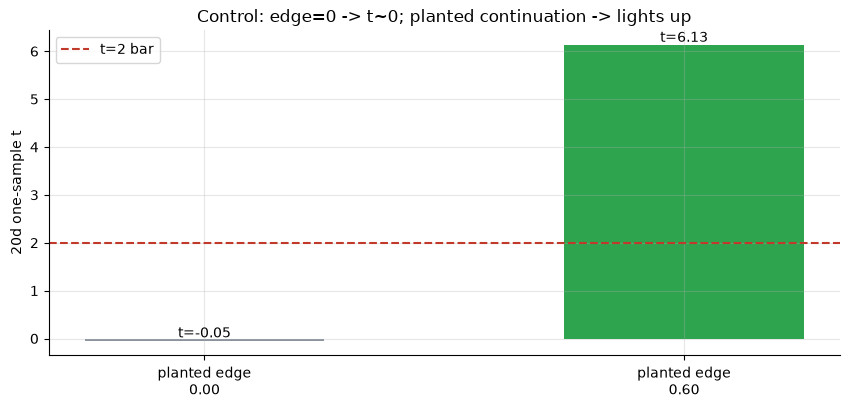

edge=0.00: n=138 rev=-2.0bps win=49% t=-0.05
edge=0.60: n=84 rev=+617.4bps win=76% t=+6.13


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=496, n_days=4000)
    c = px['close']; e = st.reversal_entries(c, n_lines=3); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} rev={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits at **t = -0.05** (win 49% — no false positive); a planted continuation reaches **t = 6.13** (win 76%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the up-reversal does not beat a drift-matched random baseline (reversal − random = +0/-28/-22/-32 bps at 5/10/20/60d; Welch t never clears 2, max **+0.02** at 5d). The impressive one-sample t's (20d **5.29**, 60d **6.26**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **3-line reversal forecasts? `BUSTED`** — the shuffled-returns placebo leaves the result untouched (**p = 0.26**): a scrambled order reverses as well as the real one, so the specific Three-Line-Break flips carry no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The up-reversal's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The TLB rule sits *out* of the market on every down-flip (missing rebounds) and pays costs on each reversal, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. Three-Line-Break is a descriptive noise-filter chart, not a forecasting strategy.

## 7 · Going further

- **The break number.** 2-line and 5-line breaks trade off whipsaws against lag, but both inherit the same drift confound — a clean follow-up sweeps the break number and shows the Welch t stays sub-2 throughout.
- **Long-short.** Shorting the down-flips adds the *negative* of drift on the short leg; raced against a random long-short baseline it fares no better.
- **Renko & Kagi.** The closest cousins (also time-independent, redraw-on-threshold charts) are affine tweaks of the same idea and inherit the same drift confound — see the Renko sibling study.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*